In [327]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from numpy import inf
from scipy.stats import kurtosis, skew

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import average_precision_score

from fair_metrics import *
import warnings
warnings.filterwarnings('ignore')

In [328]:
# df = pd.read_csv('E:\Jio_Institute\Responsible_AI\ibm_hr_data.csv')

In [329]:
# from sklearn.preprocessing import LabelEncoder

# # Create a copy of your dataset
# encoded_data = df.copy()

# # Initialize the LabelEncoder
# label_encoder = LabelEncoder()

# # Iterate through each column in the dataset
# for column in encoded_data.columns:
#     # Check if the column data type is object (categorical)
#     if encoded_data[column].dtype == 'O':
#         # Use LabelEncoder to transform the categorical values to numerical values
#         encoded_data[column] = label_encoder.fit_transform(encoded_data[column])

# # Now, 'encoded_data' contains the label-encoded version of your dataset


In [330]:
data = pd.read_csv("E:\Jio_Institute\Responsible_AI\ibm_hr_data_encoded_DP1.csv")

In [331]:
data.head().T

,0,1,2,3,4
Age,41.000000,49.000000,37.000000,33.000000,27.000000
Attrition,1.000000,0.000000,1.000000,0.000000,0.000000
BusinessTravel,2.000000,1.000000,2.000000,1.000000,2.000000
DailyRate,1102.000000,279.000000,1373.000000,1392.000000,591.000000
Department,2.000000,1.000000,1.000000,1.000000,1.000000
DistanceFromHome,1.000000,8.000000,2.000000,3.000000,2.000000
Education,2.000000,1.000000,2.000000,4.000000,1.000000
EducationField,1.000000,1.000000,4.000000,1.000000,3.000000
EmployeeCount,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1.000000,2.000000,4.000000,5.000000,7.000000


#### Select favourable and unfavourable outcome

In [332]:
data['Age'].head

<bound method NDFrame.head of 0       41
1       49
2       37
3       33
4       27
        ..
1465    36
1466    39
1467    27
1468    49
1469    34
Name: Age, Length: 1470, dtype: int64>

In [333]:
target='Attrition'

fav=1
unfav=int(not fav)

#### Identify the protected groups and the respective advantageous and disadvantageous subsets

In [334]:
label_names=['Attrition']

protected_groups = ['Gender','NumCompaniesWorked', 'JobRole','BusinessTravel',
                              'OverTime', 'MaritalStatus','Department','StockOptionLevel']

In [335]:
adv_groups = [{'Gender': 0},  {'NumCompaniesWorked': 0},
                     {'JobRole': 0},{'BusinessTravel':0}, {'OverTime': 0},{'MaritalStatus': 0},{'Department': 0},{'StockOptionLevel': 0}
                     ]

disadv_groups = [{'Gender': 1}, {'NumCompaniesWorked': 1},
                       {'JobRole': 1}, {'BusinessTravel':1},{'OverTime': 1},{'MaritalStatus': 1},{'Department': 1},{'StockOptionLevel': 1}
                    ]
SP=[]
DI=[]
Protected=[]
for groupe in range(0, len(protected_groups)):
    protected_group = list(adv_groups[groupe].keys())[0]
    adv_protected_group_value = adv_groups[groupe][protected_group]
    disadv_protected_group_value = disadv_groups[groupe][protected_group]
    statistical_parity, disparate_impact = statistical_parity_test(data, protected_group,
              adv_protected_group_value, disadv_protected_group_value, target, fav)
    
    SP.append(statistical_parity)
    DI.append(disparate_impact)
    Protected.append(protected_group)

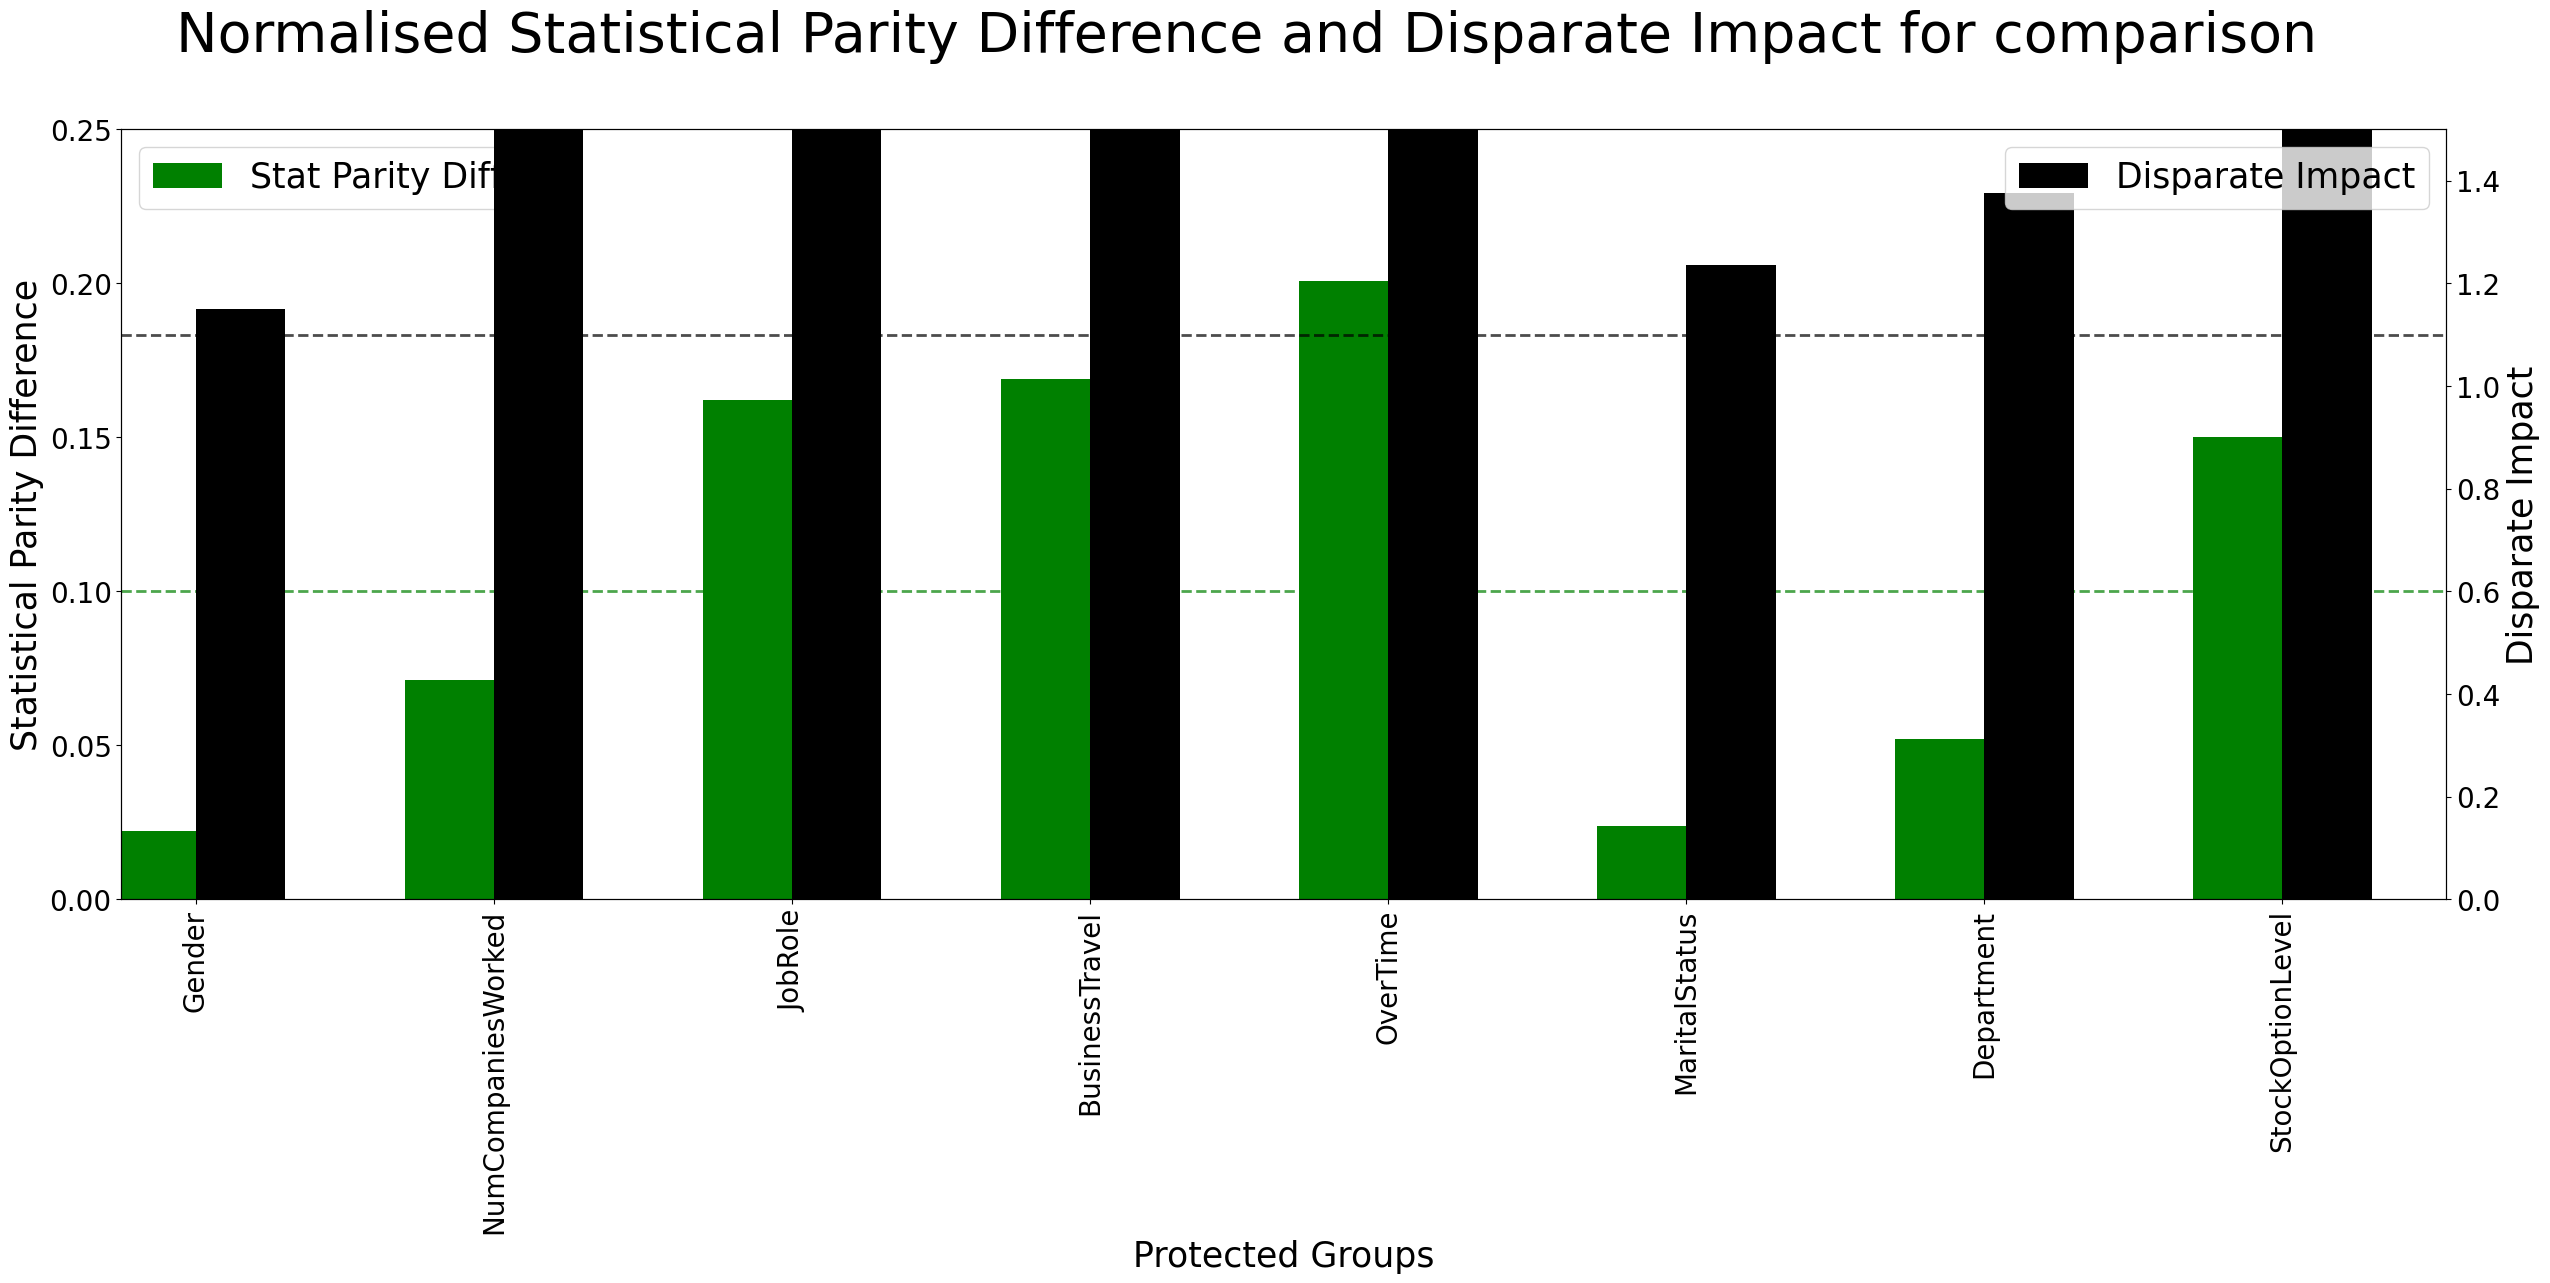

In [336]:
d = pd.DataFrame({'Protected_feature':Protected,'Statistical_Parity':SP,'Disparate_Impact':DI})
d['DI_normal']=d["Disparate_Impact"].apply(lambda x: 1/x if x < 1 else x)
d['SP_normal']=d["Statistical_Parity"].apply(lambda x: abs(x) if x < 0 else x)

fig = plt.figure() 
ax = fig.add_subplot(111) 
ax2 = ax.twinx() # Create another axes that shares the same x-axis as ax.

fig.suptitle('Normalised Statistical Parity Difference and Disparate Impact for comparison', fontsize=40, y=1)

width = 0.3
ax.set_ylim(0, 0.25) 
ax2.set_ylim(0, 1.5) 

d.plot(x ='Protected_feature', y='SP_normal', kind = 'bar', ax=ax, width=width, 
       position=1, color='green', legend=False, figsize=(30,10), fontsize=20)
d.plot(x ='Protected_feature', y='DI_normal', kind = 'bar', ax=ax2, width=width, 
       position=0, color='black', legend=False, figsize=(30,10), fontsize=20)

ax.axhline(y=0.1, linestyle='dashed', linewidth=2, alpha=0.7, color='green')
ax2.axhline(y=1.10, linestyle='dashed', linewidth=2, alpha=0.7, color='black')

patches, labels = ax.get_legend_handles_labels()
ax.legend(patches, ['Stat Parity Diff'], loc='upper left', fontsize=25)

patches, labels = ax2.get_legend_handles_labels()
ax2.legend(patches, ['Disparate Impact'], loc='upper right', fontsize=25)

labels = [item.get_text() for item in ax.get_xticklabels()]

labels[0] = 'Gender'
labels[1] = 'NumCompaniesWorked'
labels[2] = 'JobRole'
labels[3] = 'BusinessTravel'
labels[4] = 'OverTime'
labels[5] = 'MaritalStatus'
labels[6] = 'Department'

ax.set_xticklabels(labels)
ax.set_xlabel('Protected Groups', fontsize=25)
ax.set_ylabel('Statistical Parity Difference', fontsize=25)
ax2.set_ylabel('Disparate Impact', fontsize=25)

plt.show()

In [337]:
# Gender = 'Gender'
# OverTime = 'OverTime'
# MaritalStatus = 'MaritalStatus'
# StockOptionLevel = 'StockOptionLevel'

In [338]:
dataacf = data[['Attrition','Gender','NumCompaniesWorked', 'JobRole','BusinessTravel',
                              'OverTime', 'MaritalStatus','Department','StockOptionLevel','Age','DailyRate','DistanceFromHome','Education','HourlyRate','MonthlyIncome','MonthlyRate','PercentSalaryHike','TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']]

In [339]:
biased_protected_groups = ['Gender', 'OverTime', 'MaritalStatus', 'StockOptionLevel']

In [340]:
choice = 'Gender'

## Baseline model : Logistic Regression

In [341]:
y=dataacf['Attrition']
x=dataacf.drop(columns=['Attrition'])
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=6666)

In [342]:
log_reg = LogisticRegression(random_state=0, solver='liblinear',
                              multi_class='ovr').fit(X_train, y_train)

In [343]:
y_pred=log_reg.predict(X_test)
y_pred_prob=log_reg.predict_proba(X_test)[:,0]
print("Accuracy of the baseline model:", log_reg.score(X_test, y_test))

Accuracy of the baseline model: 0.8299319727891157


In [344]:
A_full=log_reg.score(X_test[X_test[choice]==0], y_test[X_test[choice]==0]) 
B_full=log_reg.score(X_test[X_test[choice]==1], y_test[X_test[choice]==1]) 
print("Accuracy difference between two groups:", abs(B_full-A_full)*100, "%")

Accuracy difference between two groups: 0.5555555555555647 %


## Additive counterfactual fair model by hand


In [345]:
y=dataacf['Attrition']
x=dataacf.drop(columns=['Attrition'])
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=6666)

In [346]:
sens=X_train[biased_protected_groups]

#### Regressing each independant variable with sensitive variable

In [347]:
acf_Age = LinearRegression().fit(sens, X_train['Age'])
acf_DailyRate = LinearRegression().fit(sens, X_train['DailyRate'])
acf_DistanceFromHome = LinearRegression().fit(sens, X_train['DistanceFromHome'])
acf_HourlyRate = LinearRegression().fit(sens, X_train['HourlyRate'])
acf_MonthlyIncome = LinearRegression().fit(sens, X_train['MonthlyIncome'])
acf_MonthlyRate = LinearRegression().fit(sens, X_train['MonthlyRate'])
acf_NumCompaniesWorked = LinearRegression().fit(sens, X_train['NumCompaniesWorked'])
acf_StockOptionLevel = LinearRegression().fit(sens, X_train['StockOptionLevel'])
acf_PercentSalaryHike = LinearRegression().fit(sens, X_train['PercentSalaryHike'])
acf_TotalWorkingYears= LinearRegression().fit(sens, X_train['TotalWorkingYears'])
acf_YearsAtCompany = LinearRegression().fit(sens, X_train['YearsAtCompany'])
acf_YearsInCurrentRole = LinearRegression().fit(sens, X_train['YearsInCurrentRole'])
acf_YearsSinceLastPromotion = LinearRegression().fit(sens, X_train['YearsSinceLastPromotion'])
acf_YearsWithCurrManager = LinearRegression().fit(sens, X_train['YearsWithCurrManager'])

#### Calculate the residuals for each model

In [348]:
AgeR = X_train['Age'] - acf_Age.predict(sens)
DailyRateR = X_train['DailyRate'] - acf_DailyRate.predict(sens)
DistanceFromHomeR = X_train['DistanceFromHome'] - acf_DistanceFromHome.predict(sens)
HourlyRateR = X_train['HourlyRate'] - acf_HourlyRate.predict(sens)
MonthlyIncomeR = X_train['MonthlyIncome'] - acf_MonthlyIncome.predict(sens)
MonthlyRateR = X_train['MonthlyRate'] - acf_MonthlyRate.predict(sens)
NumCompaniesWorkedR = X_train['NumCompaniesWorked'] - acf_NumCompaniesWorked.predict(sens)
StockOptionLevelR = X_train['StockOptionLevel'] - acf_StockOptionLevel.predict(sens)
PercentSalaryHikeR = X_train['PercentSalaryHike'] - acf_PercentSalaryHike.predict(sens)
TotalWorkingYearsR = X_train['TotalWorkingYears'] - acf_TotalWorkingYears.predict(sens)
YearsAtCompanyR = X_train['YearsAtCompany'] - acf_YearsAtCompany.predict(sens)
YearsInCurrentRoleR = X_train['YearsInCurrentRole'] - acf_YearsInCurrentRole.predict(sens)
YearsSinceLastPromotionR = X_train['YearsSinceLastPromotion'] - acf_YearsSinceLastPromotion.predict(sens)
YearsWithCurrManagerR = X_train['YearsWithCurrManager'] - acf_YearsWithCurrManager.predict(sens)

In [349]:
df_R = pd.DataFrame({
    'AgeR': AgeR,
    'DailyRateR': DailyRateR,
    'DistanceFromHomeR': DistanceFromHomeR,
    'HourlyRateR': HourlyRateR,
    'MonthlyIncomeR': MonthlyIncomeR,
    'MonthlyRateR': MonthlyRateR,
    'NumCompaniesWorkedR': NumCompaniesWorkedR,
    'StockOptionLevelR': StockOptionLevelR,
    'PercentSalaryHikeR': PercentSalaryHikeR,
    'TotalWorkingYearsR': TotalWorkingYearsR,
    'YearsAtCompanyR': YearsAtCompanyR,
    'YearsInCurrentRoleR': YearsInCurrentRoleR,
    'YearsSinceLastPromotionR': YearsSinceLastPromotionR,
    'YearsWithCurrManagerR': YearsWithCurrManagerR
})

In [350]:
df_R

,AgeR,DailyRateR,DistanceFromHomeR,HourlyRateR,MonthlyIncomeR,MonthlyRateR,NumCompaniesWorkedR,StockOptionLevelR,PercentSalaryHikeR,TotalWorkingYearsR,YearsAtCompanyR,YearsInCurrentRoleR,YearsSinceLastPromotionR,YearsWithCurrManagerR
533,2.979713,-221.945969,-4.532543,-17.522168,3468.264280,9496.805560,2.465159,0.000000e+00,5.673848,8.724723,11.121691,8.930786,-1.156948,8.058904
319,-5.799367,-243.357144,-0.807445,-0.306308,3341.984344,9502.543466,-1.629369,-1.991463e-15,-4.160471,0.604686,5.502675,7.782968,8.772007,4.771690
644,-6.020287,420.054031,1.467457,-17.522168,-48.669148,595.805560,0.465159,0.000000e+00,3.673848,-3.275277,-0.878309,-0.069214,-2.156948,-1.941096
427,22.602684,660.146304,19.326680,14.804086,28207.885799,-12112.818489,1.268074,-1.630640e-15,4.013089,9.906415,10.421792,8.617830,10.701135,6.535957
268,7.787596,566.234583,11.122538,15.037873,4705.430381,-7146.439226,-2.457997,-1.829327e-15,-1.216848,9.019262,12.696476,2.906027,1.789301,5.975302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,11.766206,13.543685,-7.229609,33.406069,9358.023650,-9546.308767,-1.686785,-1.554312e-15,-4.092679,18.453411,23.051419,1.378726,11.510734,2.529826
382,-9.194797,-193.248175,-5.912146,8.330424,28853.508688,-7923.048808,-2.511166,3.425465e-16,6.896799,-3.105969,-0.395017,0.127812,-2.020125,0.032914
102,-16.183810,97.656650,-2.976255,-0.124151,64120.526259,4640.295838,-1.579982,-1.804112e-16,2.779617,-9.822274,-5.507936,-3.830110,-0.966546,-3.934965
665,10.816190,680.656650,-6.976255,-1.124151,8499.834544,-2005.704162,-1.579982,-1.804112e-16,2.779617,-7.822274,-3.507936,-1.830110,-0.966546,-1.934965


Fitting residuals to the dependent (target) variable

In [351]:
fair = LogisticRegression(random_state=12, solver='liblinear').fit(df_R, y_train)

#### Calculate residuals for the test data

In [352]:
sens=X_test[biased_protected_groups]

In [353]:
AgeR = X_test['Age'] - acf_Age.predict(sens)
DailyRateR = X_test['DailyRate'] - acf_DailyRate.predict(sens)
DistanceFromHomeR = X_test['DistanceFromHome'] - acf_DistanceFromHome.predict(sens)
HourlyRateR = X_test['HourlyRate'] - acf_HourlyRate.predict(sens)
MonthlyIncomeR = X_test['MonthlyIncome'] - acf_MonthlyIncome.predict(sens)
MonthlyRateR = X_test['MonthlyRate'] - acf_MonthlyRate.predict(sens)
NumCompaniesWorkedR = X_test['NumCompaniesWorked'] - acf_NumCompaniesWorked.predict(sens)
StockOptionLevelR = X_test['StockOptionLevel'] - acf_StockOptionLevel.predict(sens)
PercentSalaryHikeR = X_test['PercentSalaryHike'] - acf_PercentSalaryHike.predict(sens)
TotalWorkingYearsR = X_test['TotalWorkingYears'] - acf_TotalWorkingYears.predict(sens)
YearsAtCompanyR = X_test['YearsAtCompany'] - acf_YearsAtCompany.predict(sens)
YearsInCurrentRoleR = X_test['YearsInCurrentRole'] - acf_YearsInCurrentRole.predict(sens)
YearsSinceLastPromotionR = X_test['YearsSinceLastPromotion'] - acf_YearsSinceLastPromotion.predict(sens)
YearsWithCurrManagerR = X_test['YearsWithCurrManager'] - acf_YearsWithCurrManager.predict(sens)

In [354]:
df_R_test = pd.DataFrame({
    'AgeR': AgeR,
    'DailyRateR': DailyRateR,
    'DistanceFromHomeR': DistanceFromHomeR,
    'HourlyRateR': HourlyRateR,
    'MonthlyIncomeR': MonthlyIncomeR,
    'MonthlyRateR': MonthlyRateR,
    'NumCompaniesWorkedR': NumCompaniesWorkedR,
    'StockOptionLevelR': StockOptionLevelR,
    'PercentSalaryHikeR': PercentSalaryHikeR,
    'TotalWorkingYearsR': TotalWorkingYearsR,
    'YearsAtCompanyR': YearsAtCompanyR,
    'YearsInCurrentRoleR': YearsInCurrentRoleR,
    'YearsSinceLastPromotionR': YearsSinceLastPromotionR,
    'YearsWithCurrManagerR': YearsWithCurrManagerR
})

In [355]:
y_pred_fair = fair.predict(df_R_test)
y_pred_prob_fair = fair.predict_proba(df_R_test)

In [373]:
from sklearn.metrics import mean_squared_error 
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("For ACF model:")
print("Mean Squared Error: ",mean_squared_error(y_test, y_pred_fair))
print("Root Mean Squared Error : ",rmse(y_pred_fair,y_test))
print("Mean Absolute Error:", mape(y_pred_fair, y_test)) 

For ACF model:
Mean Squared Error:  0.17346938775510204
Root Mean Squared Error :  0.41649656391752143
Mean Absolute Error: inf


In [356]:
print("Accuracy of the fair model:", fair.score(df_R_test, y_test))

Accuracy of the fair model: 0.826530612244898


In [357]:
A_full=fair.score(df_R_test[sens[choice]==0], y_test[sens[choice]==0]) 
B_full=fair.score(df_R_test[sens[choice]==1], y_test[sens[choice]==1]) 
print("Accuracy difference between two groups:", abs(B_full-A_full)*100, "%")

Accuracy difference between two groups: 0.3216374269005784 %


In [358]:
tn_disadv, fp_disadv, fn_disadv, tp_disadv = confusion_matrix(y_test[sens[choice]==0], y_pred_fair[sens[choice]==0]).ravel()
tn_adv, fp_adv, fn_adv, tp_adv = confusion_matrix(y_test[sens[choice]==1], y_pred_fair[sens[choice]==1]).ravel()

acf_metrics = acf_fair_metrics(tn_disadv, fp_disadv, fn_disadv, tp_disadv, tn_adv, fp_adv, fn_adv, tp_adv)
acf_metrics

[('Equal Opps', 0.0),
 ('PredEq', 0.003859649122807017),
 ('Equal Odds', 0.003859649122807017),
 ('PredParity', 0.0),
 ('DemoParity', 0.0032163742690058473),
 ('AOD', 0.0019298245614035084),
 ('TEq', 11.0)]

## Additive Counterfactual Model using the class

In [359]:
independent_vars = ['NumCompaniesWorked', 'JobRole','BusinessTravel',
                               'Department','Age','DailyRate','DistanceFromHome','Education','HourlyRate','MonthlyIncome','MonthlyRate','PercentSalaryHike','TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']
biased_protected_groups = ['Gender', 'OverTime', 'MaritalStatus', 'StockOptionLevel']

sens_train = X_train[biased_protected_groups]
sens_test = X_test[biased_protected_groups]

In [360]:
import ACF as acf_class

acf = acf_class.ACF(X_train, X_test, y_train, y_test, sens_train, sens_test, 
                    independent_vars)

main_model = LogisticRegression(random_state=12, 
                                solver='liblinear')

acf_model = acf.fit(main_model)

In [361]:
y_pred_fair_class = acf.predict()

In [362]:
y_pred_prob_class = acf.predict_proba()

In [363]:
acf.score()

Accuracy of additive counterfactual fair model: 0.826530612244898


0.826530612244898

## Model Fairness Metrics

In [364]:
tn_disadv, fp_disadv, fn_disadv, tp_disadv = acf.confusion_mat(choice, 0)
tn_adv, fp_adv, fn_adv, tp_adv = acf.confusion_mat(choice, 1)

In [365]:
acf_metrics = acf_fair_metrics(tn_disadv, fp_disadv, fn_disadv, tp_disadv, tn_adv, fp_adv, fn_adv, tp_adv)
acf_metrics

[('Equal Opps', 0.0),
 ('PredEq', 0.003859649122807017),
 ('Equal Odds', 0.003859649122807017),
 ('PredParity', 0.0),
 ('DemoParity', 0.0032163742690058473),
 ('AOD', 0.0019298245614035084),
 ('TEq', 11.0)]

In [366]:
logistic_reg_fair_metrics = fair_metrics(y_test, y_pred_prob, y_pred, X_test, choice, 1, 0)
logistic_reg_fair_metrics

[('AUC', 0.0692582333025546),
 ('Avg PrecScore', 0.020485083113333663),
 ('Equal Opps', 0.024561403508772006),
 ('PredEq', 0.0017543859649122792),
 ('Equal Odds', 0.022807017543859637),
 ('PredParity', 0.05555555555555558),
 ('DemoParity', 0.0026315789473684154),
 ('AOD', 0.011403508771929822),
 ('TEq', 0.13333333333333286)]

In [367]:
labels, log_reg_model = zip(*logistic_reg_fair_metrics)
headers, acf_model = zip(*acf_metrics)
ACF={'Metrics':headers[0:6], 
             'Baseline Model':list(log_reg_model[2:8]), 'ACF Fair Model':list(acf_model[0:6])}
ACF_table=pd.DataFrame.from_dict(ACF)
ACF_table

,Metrics,Baseline Model,ACF Fair Model
0,Equal Opps,0.024561,0.000000
1,PredEq,0.001754,0.003860
2,Equal Odds,0.022807,0.003860
3,PredParity,0.055556,0.000000
4,DemoParity,0.002632,0.003216
5,AOD,0.011404,0.001930


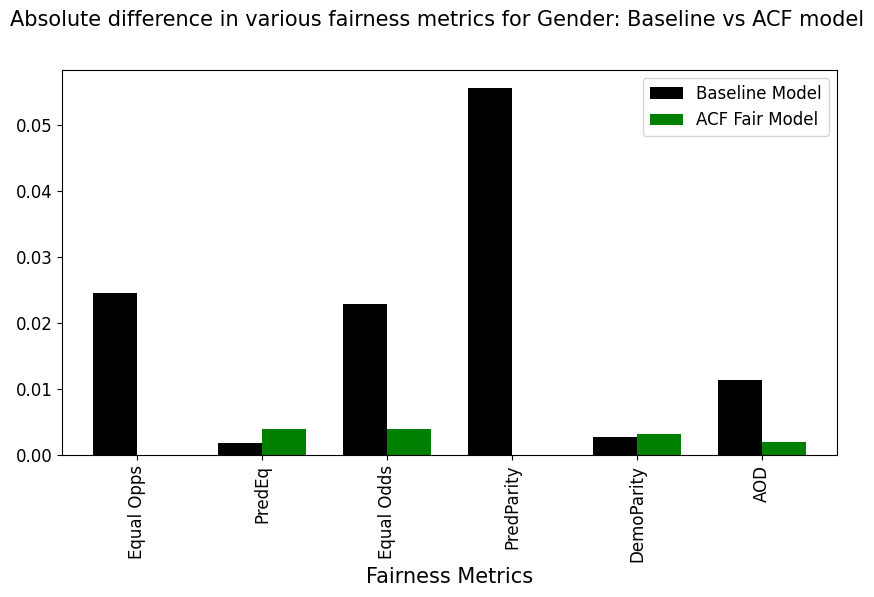

In [368]:
ax = ACF_table.plot.bar(x='Metrics', rot=90, width = 0.7, color=['black', 'green'], figsize=(10,5), fontsize=12)
plt.suptitle('Absolute difference in various fairness metrics for {}: Baseline vs ACF model'.format(choice),  
             fontsize=15, y=1)

patches, labels = ax.get_legend_handles_labels()
ax.legend(patches, labels, loc='upper right', fontsize=12)

ax.set_xlabel('Fairness Metrics', fontsize=15)
plt.show()

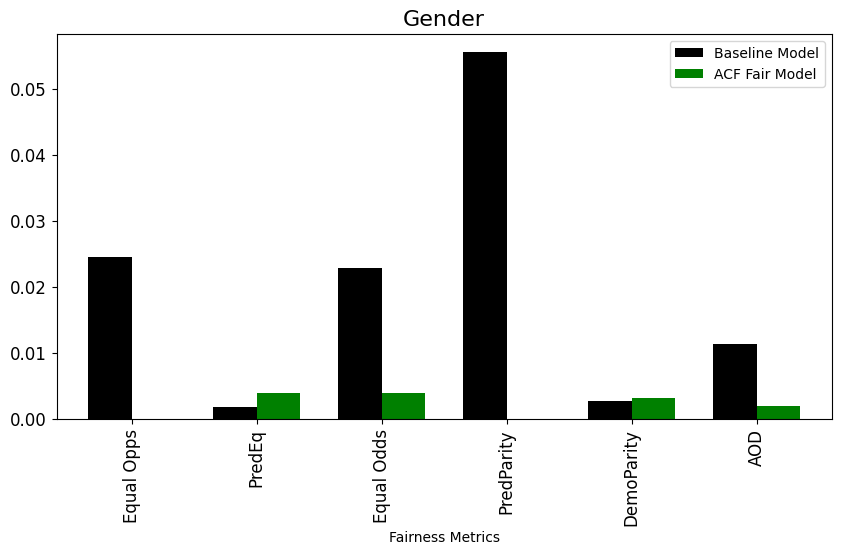

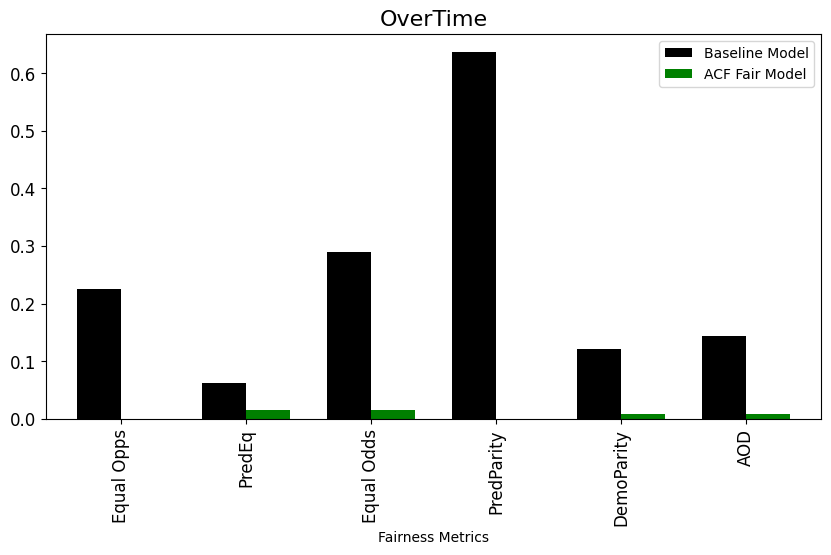

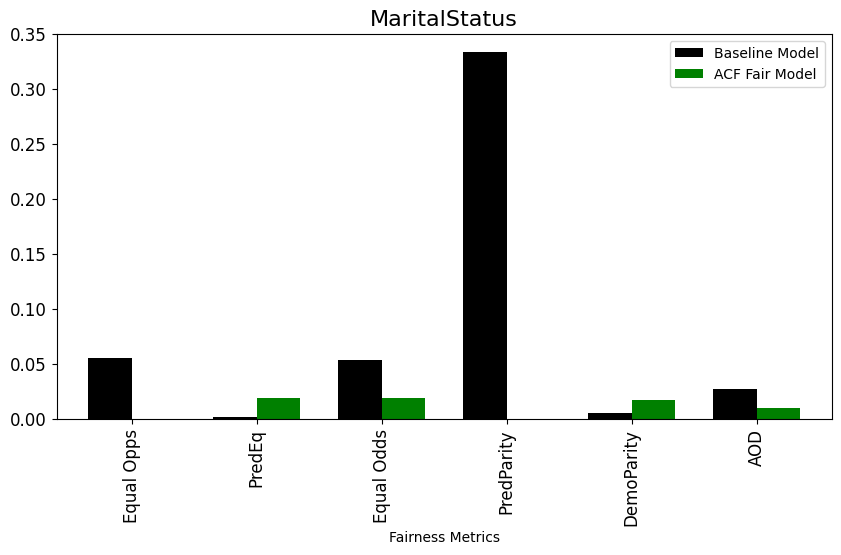

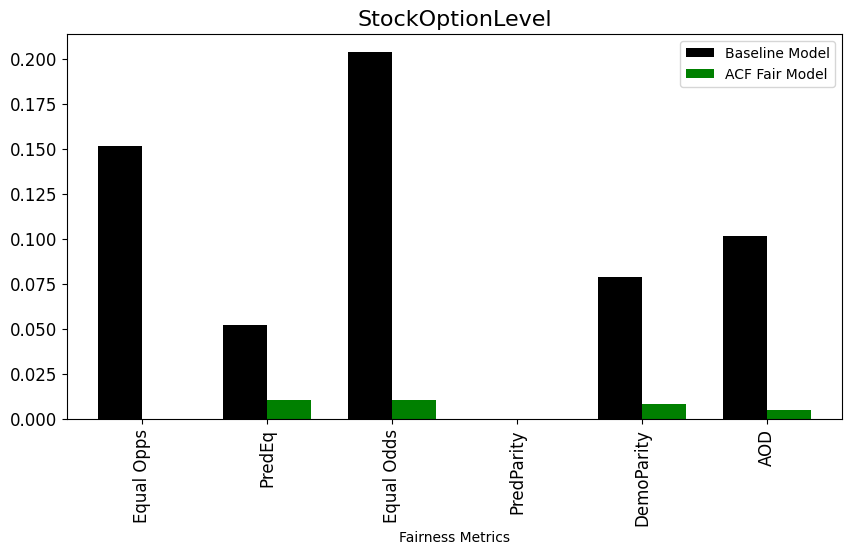

In [369]:
for groupe in range(0, len(biased_protected_groups)):
    choice = biased_protected_groups[groupe]
    protected_group = list(adv_groups[groupe].keys())[0]
    adv_protected_group_value = adv_groups[groupe][protected_group]
    disadv_protected_group_value = disadv_groups[groupe][protected_group]
    
    tn_disadv, fp_disadv, fn_disadv, tp_disadv = acf.confusion_mat(choice, disadv_protected_group_value)
    tn_adv, fp_adv, fn_adv, tp_adv = acf.confusion_mat(choice, adv_protected_group_value)
    
    acf_metrics = acf_fair_metrics(tn_disadv, fp_disadv, fn_disadv, tp_disadv, tn_adv, fp_adv, fn_adv, tp_adv)
    logistic_reg_fair_metrics = fair_metrics(y_test, y_pred_prob, y_pred, X_test, choice, adv_protected_group_value, disadv_protected_group_value)
    
    labels, log_reg_model = zip(*logistic_reg_fair_metrics)
    headers, acf_model = zip(*acf_metrics)
    ACF={'Fairness Metrics':headers[0:6], 
             'Baseline Model':list(log_reg_model[2:8]), 'ACF Fair Model':list(acf_model[0:6])}
    ACF_table=pd.DataFrame.from_dict(ACF) 
    
    ax = ACF_table.plot.bar(x='Fairness Metrics', rot=90, width = 0.7, color=['black', 'green'], figsize=(10,5), fontsize=12)
    plt.title(choice, fontsize=16)
plt.show()

## Model performance metrics 

In [370]:
model_perf=[accuracy_metrics(y_test, y_pred_prob, y_pred_prob_class, 
                          y_pred, y_pred_fair_class, X_test)]

headers=["AUC", "Gini", "Avg Precision Score", "Precision", "Sensitivity", "False Negative Rate", 
         "F1 Score"]

B = list(model_perf[0])[:len(list(model_perf[0]))//2]
C = list(model_perf[0])[len(list(model_perf[0]))//2:]


model_table={'Metrics':headers, 
             'Baseline':B, 'ACF':C}

model_table_df=pd.DataFrame.from_dict(model_table)
model_table_df

,Metrics,Baseline,ACF
0,AUC,0.224990,0.353769
1,Gini,-0.550021,-0.292461
2,Avg Precision Score,0.209524,0.166667
3,Precision,0.466667,0.000000
4,Sensitivity,0.142857,0.000000
5,False Negative Rate,0.857143,1.000000
6,F1 Score,0.218750,NaN


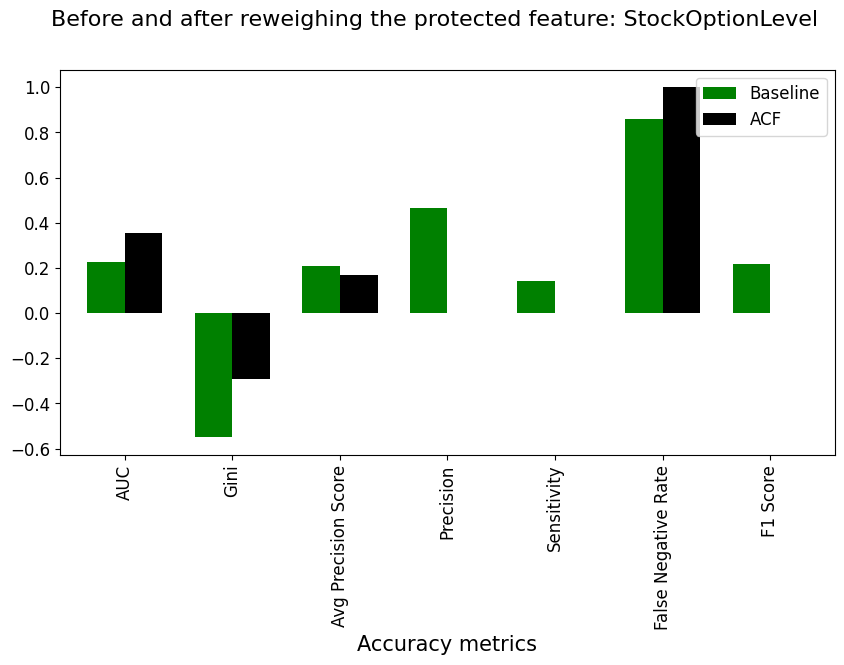

In [371]:
ax = model_table_df.iloc[:,:].plot.bar(x='Metrics', rot=90, width = 0.7, 
                                                       color=['green', 'black'], figsize=(10,5), fontsize=12)
plt.suptitle('Before and after reweighing the protected feature: {}'.format(choice),  fontsize=16, y=1)



patches, labels = ax.get_legend_handles_labels()
ax.legend(patches, labels, loc='upper right', fontsize=12)

ax.set_xlabel('Accuracy metrics', fontsize=15)

plt.show()